In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
import scipy as sp
from joblib import Parallel, delayed
import pandas as pd
import itertools
from qutip.qip.operations import rz, cz_gate, cnot, rx, hadamard_transform

In [2]:

f_1000_False = np.array([
# -0.31308179, -0.3807945, -0.45595414, -0.53517053 ,
# -0.62362769, -0.72035237, -0.83263802, -0.96721885 ,
# -1.13427921, -1.32287436, -1.54607246, -1.7622428 ,
-0.34054968, -0.41997718, -0.50564597, -0.5939843 ,
-0.68709508, -0.78070633, -0.87685505, -0.99119013 ,
-1.14375368, -1.32503677, -1.52064501, -1.70110197 ,

-1.91027038, -2.05780752, -2.25166149, -2.40898086 ,
-2.53251749, -2.64483378, -2.76168067, -2.84286097 ,
-2.91236387, -2.98764623,
-3.06275222, -3.11288779, -3.16480377, -3.21686124 ,
-3.27490824, -3.31894369, -3.36162247, -3.38447308 ,
-3.44311243, -3.47404681 ,
])
f_200_short = np.array([
# -0.31416804, -0.37953706, -0.45328995, -0.53253985 ,
# -0.62055602, -0.71817058, -0.82997394, -0.96321383 ,
# -1.12520033, -1.30663352, -1.51335307, -1.70079442 ,
-0.32771536, -0.40479492, -0.50248238, -0.61223336 ,
-0.7107132, -0.80872123, -0.89987692, -1.00746973 ,
-1.16106707, -1.35282295, -1.58074169, -1.77567846 ,

-1.84956121, -2.00077611, -2.20239633, -2.39116377 ,
-2.52671861, -2.65070337, -2.76713919, -2.84964821 ,
-2.92073169, -2.99583451,
-3.06948985, -3.12317876, -3.17088505, -3.23079202 ,
-3.28362895, -3.32560041, -3.36561736, -3.40713702 ,
-3.45147331, -3.4870657 ,
])
para = np.array([
# [30.01162, 0.10169, 0.044983, -0.009811, -0.009766] ,
# [40.014074, 0.085444, 0.03794, -0.00987, -0.009874] ,
# [50.005145, 0.078375, 0.034478, -0.009941, -0.009926] ,
# [60.017067, 0.069601, 0.032036, -0.00987, -0.009726] ,
# [69.995489, 0.063351, 0.029729, -0.009859, -0.009981] ,
# [80.00902, 0.057964, 0.029654, -0.009943, -0.009989] ,
# [90.007516, 0.054955, 0.028574, -0.009961, -0.009968] ,
# [100.009188, 0.051464, 0.028152, -0.00999, -0.009967] ,
# [110.007023, 0.048962, 0.027303, -0.01, -0.00999] ,
# [119.996501, 0.045946, 0.026419, -0.009876, -0.009588] ,
# [129.989151, 0.043855, 0.02623, -0.009997, -0.00958] ,
# [140.008976, 0.041195, 0.025523, -0.009916, -0.009373] ,
[30.016865, 0.119046, 0.056799, -0.032063, -0.030732] ,
[40.016766, 0.104833, 0.049914, -0.030496, -0.028693] ,
[50.008813, 0.090273, 0.046546, -0.027498, -0.025767] ,
[60.024831, 0.074075, 0.039782, -0.020488, -0.019859] ,
[69.994995, 0.065867, 0.034625, -0.016253, -0.015833] ,
[80.005168, 0.061271, 0.032441, -0.015181, -0.014477] ,
[90.004882, 0.057133, 0.030909, -0.013363, -0.01325] ,
[100.006167, 0.053076, 0.029316, -0.01188, -0.01157] ,
[110.008706, 0.049616, 0.028206, -0.01119, -0.010777] ,
[119.999923, 0.046969, 0.027146, -0.010649, -0.010409] ,
[129.995414, 0.044102, 0.026819, -0.010756, -0.010313] ,
[140.005331, 0.041394, 0.025794, -0.010206, -0.009612] ,

[149.996866, 0.039078, 0.024359, -0.009107, -0.008681] ,
[160.000133, 0.036595, 0.022959, -0.008237, -0.007826] ,
[169.993992, 0.034622, 0.02211, -0.007681, -0.007266] ,
[179.996641, 0.032821, 0.02095, -0.006902, -0.006534] ,
[189.997344, 0.030915, 0.019755, -0.006194, -0.005848] ,
[200.001513, 0.029121, 0.018721, -0.005572, -0.005265] ,
[209.996351, 0.02774, 0.017771, -0.005024, -0.004777] ,
[219.997562, 0.026349, 0.016887, -0.00455, -0.004302] ,
[230.001715, 0.025067, 0.016064, -0.00409, -0.003877] ,
[239.989977, 0.023957, 0.015387, -0.003744, -0.003546] ,
[249.992868, 0.022922, 0.014688, -0.003423, -0.003252] ,
[260.000623, 0.021992, 0.014066, -0.003138, -0.002978] ,
[269.994868, 0.021106, 0.013544, -0.002882, -0.002747] ,
[280.000886, 0.020289, 0.013002, -0.002675, -0.002543] ,
[290.001675, 0.019575, 0.01252, -0.00247, -0.002353] ,
[300.003294, 0.018943, 0.012103, -0.002317, -0.002203] ,
[310.008159, 0.018298, 0.011686, -0.002157, -0.002061] ,
[319.999489, 0.01768, 0.011265, -0.002005, -0.001905] ,
[330.004173, 0.017153, 0.010944, -0.001891, -0.001804] ,
[340.0063, 0.016618, 0.010608, -0.001774, -0.00169] ,
])
p = np.column_stack((para, f_200_short, f_1000_False))
for i in p:
    print(i.tolist(), ',')
# p.tolist()

[30.016865, 0.119046, 0.056799, -0.032063, -0.030732, -0.32771536, -0.34054968] ,
[40.016766, 0.104833, 0.049914, -0.030496, -0.028693, -0.40479492, -0.41997718] ,
[50.008813, 0.090273, 0.046546, -0.027498, -0.025767, -0.50248238, -0.50564597] ,
[60.024831, 0.074075, 0.039782, -0.020488, -0.019859, -0.61223336, -0.5939843] ,
[69.994995, 0.065867, 0.034625, -0.016253, -0.015833, -0.7107132, -0.68709508] ,
[80.005168, 0.061271, 0.032441, -0.015181, -0.014477, -0.80872123, -0.78070633] ,
[90.004882, 0.057133, 0.030909, -0.013363, -0.01325, -0.89987692, -0.87685505] ,
[100.006167, 0.053076, 0.029316, -0.01188, -0.01157, -1.00746973, -0.99119013] ,
[110.008706, 0.049616, 0.028206, -0.01119, -0.010777, -1.16106707, -1.14375368] ,
[119.999923, 0.046969, 0.027146, -0.010649, -0.010409, -1.35282295, -1.32503677] ,
[129.995414, 0.044102, 0.026819, -0.010756, -0.010313, -1.58074169, -1.52064501] ,
[140.005331, 0.041394, 0.025794, -0.010206, -0.009612, -1.77567846, -1.70110197] ,
[149.996866, 0.03

In [4]:
x0_vec = np.array([
[30.016865, 0.119046, 0.056799, -0.032063, -0.030732] ,
[40.016766, 0.104833, 0.049914, -0.030496, -0.028693] ,
[50.008813, 0.090273, 0.046546, -0.027498, -0.025767] ,
[60.024831, 0.074075, 0.039782, -0.020488, -0.019859] ,
[69.994995, 0.065867, 0.034625, -0.016253, -0.015833] ,
[80.005168, 0.061271, 0.032441, -0.015181, -0.014477] ,
[90.004882, 0.057133, 0.030909, -0.013363, -0.01325] ,
[100.006167, 0.053076, 0.029316, -0.01188, -0.01157] ,
[110.008706, 0.049616, 0.028206, -0.01119, -0.010777] ,
[119.999923, 0.046969, 0.027146, -0.010649, -0.010409] ,
[129.995414, 0.044102, 0.026819, -0.010756, -0.010313] ,
[140.005331, 0.041394, 0.025794, -0.010206, -0.009612] ,

[149.996866, 0.039078, 0.024359, -0.009107, -0.008681] ,
[160.000133, 0.036595, 0.022959, -0.008237, -0.007826] ,
[169.993992, 0.034622, 0.02211, -0.007681, -0.007266] ,
[179.996641, 0.032821, 0.02095, -0.006902, -0.006534] ,
[189.997344, 0.030915, 0.019755, -0.006194, -0.005848] ,
[200.001513, 0.029121, 0.018721, -0.005572, -0.005265] ,
[209.996351, 0.02774, 0.017771, -0.005024, -0.004777] ,
[219.997562, 0.026349, 0.016887, -0.00455, -0.004302] ,
[230.001715, 0.025067, 0.016064, -0.00409, -0.003877] ,
[239.989977, 0.023957, 0.015387, -0.003744, -0.003546] ,
[249.992868, 0.022922, 0.014688, -0.003423, -0.003252] ,
[260.000623, 0.021992, 0.014066, -0.003138, -0.002978] ,
[269.994868, 0.021106, 0.013544, -0.002882, -0.002747] ,
[280.000886, 0.020289, 0.013002, -0.002675, -0.002543] ,
[290.001675, 0.019575, 0.01252, -0.00247, -0.002353] ,
[300.003294, 0.018943, 0.012103, -0.002317, -0.002203] ,
[310.008159, 0.018298, 0.011686, -0.002157, -0.002061] ,
[319.999489, 0.01768, 0.011265, -0.002005, -0.001905] ,
[330.004173, 0.017153, 0.010944, -0.001891, -0.001804] ,
[340.0063, 0.016618, 0.010608, -0.001774, -0.00169] ,
])[[0, 5, 15, 25, 30],:]
x0_vec

array([[ 3.00168650e+01,  1.19046000e-01,  5.67990000e-02,
        -3.20630000e-02, -3.07320000e-02],
       [ 8.00051680e+01,  6.12710000e-02,  3.24410000e-02,
        -1.51810000e-02, -1.44770000e-02],
       [ 1.79996641e+02,  3.28210000e-02,  2.09500000e-02,
        -6.90200000e-03, -6.53400000e-03],
       [ 2.80000886e+02,  2.02890000e-02,  1.30020000e-02,
        -2.67500000e-03, -2.54300000e-03],
       [ 3.30004173e+02,  1.71530000e-02,  1.09440000e-02,
        -1.89100000e-03, -1.80400000e-03]])

In [3]:
len(para)

32

In [4]:
tg5 = [30, 100, 200, 300, 340]
f5_2000_False = np.array([
-0.3149860245852747, -0.9300882805228751, -2.2098832576500405, -3.312752925463636 ,
-3.4671465576544627 ,
])
tg6 = [130, 160, 190, 220, 250, 280]
f6_2000_False = np.array([
-1.4615640403117232, -1.779661292672841, -2.0974517096954832, -2.4151999992612594 ,
-2.933019595716111, -3.1914845516432413 ,
])


p = np.array([
[30.016865, 0.119046, 0.056799, -0.032063, -0.030732, -0.32771536, -0.34054968] ,
[40.016766, 0.104833, 0.049914, -0.030496, -0.028693, -0.40479492, -0.41997718] ,
[50.008813, 0.090273, 0.046546, -0.027498, -0.025767, -0.50248238, -0.50564597] ,
[60.024831, 0.074075, 0.039782, -0.020488, -0.019859, -0.61223336, -0.5939843] ,
[69.994995, 0.065867, 0.034625, -0.016253, -0.015833, -0.7107132, -0.68709508] ,
[80.005168, 0.061271, 0.032441, -0.015181, -0.014477, -0.80872123, -0.78070633] ,
[90.004882, 0.057133, 0.030909, -0.013363, -0.01325, -0.89987692, -0.87685505] ,
[100.006167, 0.053076, 0.029316, -0.01188, -0.01157, -1.00746973, -0.99119013] ,
[110.008706, 0.049616, 0.028206, -0.01119, -0.010777, -1.16106707, -1.14375368] ,
[119.999923, 0.046969, 0.027146, -0.010649, -0.010409, -1.35282295, -1.32503677] ,
[129.995414, 0.044102, 0.026819, -0.010756, -0.010313, -1.58074169, -1.52064501] ,
[140.005331, 0.041394, 0.025794, -0.010206, -0.009612, -1.77567846, -1.70110197] ,
[149.996866, 0.039078, 0.024359, -0.009107, -0.008681, -1.84956121, -1.91027038] ,
[160.000133, 0.036595, 0.022959, -0.008237, -0.007826, -2.00077611, -2.05780752] ,
[169.993992, 0.034622, 0.02211, -0.007681, -0.007266, -2.20239633, -2.25166149] ,
[179.996641, 0.032821, 0.02095, -0.006902, -0.006534, -2.39116377, -2.40898086] ,
[189.997344, 0.030915, 0.019755, -0.006194, -0.005848, -2.52671861, -2.53251749] ,
[200.001513, 0.029121, 0.018721, -0.005572, -0.005265, -2.65070337, -2.64483378] ,
[209.996351, 0.02774, 0.017771, -0.005024, -0.004777, -2.76713919, -2.76168067] ,
[219.997562, 0.026349, 0.016887, -0.00455, -0.004302, -2.84964821, -2.84286097] ,
[230.001715, 0.025067, 0.016064, -0.00409, -0.003877, -2.92073169, -2.91236387] ,
[239.989977, 0.023957, 0.015387, -0.003744, -0.003546, -2.99583451, -2.98764623] ,
[249.992868, 0.022922, 0.014688, -0.003423, -0.003252, -3.06948985, -3.06275222] ,
[260.000623, 0.021992, 0.014066, -0.003138, -0.002978, -3.12317876, -3.11288779] ,
[269.994868, 0.021106, 0.013544, -0.002882, -0.002747, -3.17088505, -3.16480377] ,
[280.000886, 0.020289, 0.013002, -0.002675, -0.002543, -3.23079202, -3.21686124] ,
[290.001675, 0.019575, 0.01252, -0.00247, -0.002353, -3.28362895, -3.27490824] ,
[300.003294, 0.018943, 0.012103, -0.002317, -0.002203, -3.32560041, -3.31894369] ,
[310.008159, 0.018298, 0.011686, -0.002157, -0.002061, -3.36561736, -3.36162247] ,
[319.999489, 0.01768, 0.011265, -0.002005, -0.001905, -3.40713702, -3.38447308] ,
[330.004173, 0.017153, 0.010944, -0.001891, -0.001804, -3.45147331, -3.44311243] ,
[340.0063, 0.016618, 0.010608, -0.001774, -0.00169, -3.4870657, -3.47404681] ,
])

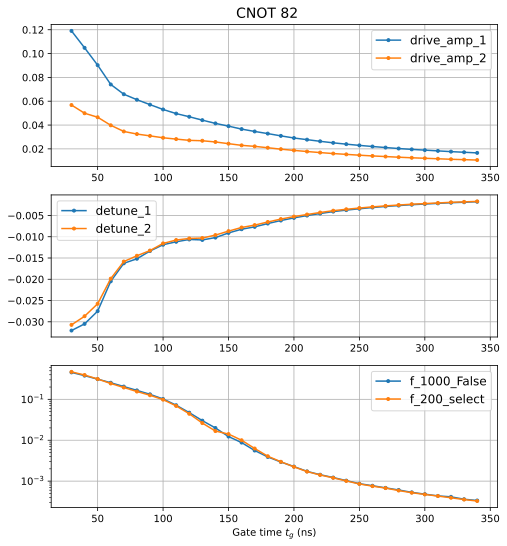

In [6]:
fig, ax = plt.subplots(figsize=(8,8), nrows=3)
fig.suptitle('CNOT 82', fontsize=14)
fig.subplots_adjust(top=0.95)
ax[0].plot(para[:,0], para[:,1], '.-',  label=r'drive_amp_1')
ax[0].plot(para[:,0], para[:,2], '.-',  label=r'drive_amp_2')
ax[1].plot(para[:,0], para[:,3], '.-',  label=r'detune_1')
ax[1].plot(para[:,0], para[:,4], '.-',  label=r'detune_2')
ax[2].plot(para[:,0], 10**f_1000_False, '.-',  label=r'f_1000_False')
# ax[2].plot(tg5, 10**f5_2000_False, 'x',  label=r'f5_2000_False')
# ax[2].plot(tg6, 10**f6_2000_False, 'x',  label=r'f6_2000_False')
ax[2].plot(para[:,0], 10**f_200_short, '.-',  label=r'f_200_select')

plt.xlabel('Gate time $t_g$ (ns)')
ax[2].set_yscale('log')
for i in range(3):
    ax[i].legend(loc='best', fontsize=12)
    ax[i].grid()